In [1]:
# ============================================================================
# IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import joblib
import os
from datetime import datetime

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports OK")
print(f"TensorFlow version: {tf.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ Imports OK
TensorFlow version: 2.16.1
Numpy version: 1.26.4
Pandas version: 2.3.3


In [ ]:
# ============================================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================================

print("\n" + "="*60)
print("📂 CHARGEMENT DES DONNÉES")  
print("="*60)

# Chemins
DATA_DIR = "../data/water_training_split"
MODEL_DIR = "../api/ml"

# Créer le dossier de sortie si besoin
os.makedirs(MODEL_DIR, exist_ok=True)

# Chargement
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df = pd.read_csv(f"{DATA_DIR}/val.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"✓ Train: {train_df.shape[0]} échantillons")
print(f"✓ Val:   {val_df.shape[0]} échantillons")
print(f"✓ Test:  {test_df.shape[0]} échantillons")

# Affichage des premières lignes
print("\n📊 Aperçu des données (train):")
print(train_df.head())


📂 CHARGEMENT DES DONNÉES
✓ Train: 700 échantillons
✓ Val:   150 échantillons
✓ Test:  150 échantillons

📊 Aperçu des données (train):
   temperature_celsius  humidity_percent  rainfall_mm  evapotranspiration_mm  \
0                 25.1              78.1         38.1                    3.9   
1                 27.7              84.6          7.5                    4.4   
2                 29.0              84.1          8.5                    4.2   
3                 20.4              80.4         12.5                    4.2   
4                 29.2              92.2          4.5                    5.0   

   wind_speed_kmh  soil_moisture_percent soil_type growth_stage  \
0             6.7                   82.7      peat  germination   
1            23.0                   88.3      clay   vegetative   
2            15.0                   68.2      peat  germination   
3            18.9                   40.4      peat   maturation   
4            22.8                   70.3     loam


📊 ANALYSE EXPLORATOIRE

📈 Statistiques de la variable cible (water_need_mm_per_day):
count    700.000000
mean      64.797486
std       26.074515
min        6.250000
25%       43.777500
50%       61.485000
75%       93.572500
max      100.000000
Name: water_need_mm_per_day, dtype: float64
✓ Graphiques sauvegardés: api/ml/eda_analysis.png

🔗 Corrélations avec la variable cible:
water_need_mm_per_day    1.000000
wind_speed_kmh           0.061792
temperature_celsius     -0.000596
evapotranspiration_mm   -0.002175
humidity_percent        -0.029731
rainfall_mm             -0.202689
soil_moisture_percent   -0.239359
Name: water_need_mm_per_day, dtype: float64


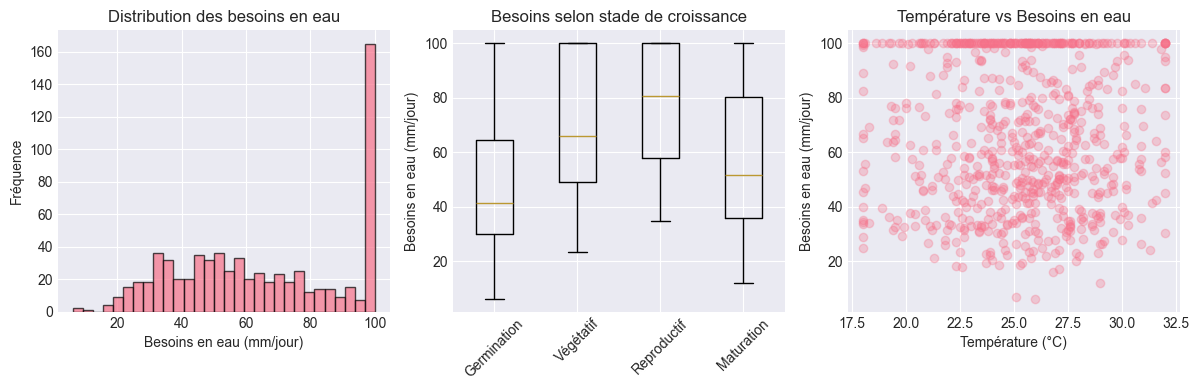

In [3]:
# ============================================================================
# 2. ANALYSE EXPLORATOIRE (EDA)
# ============================================================================

print("\n" + "="*60)
print("📊 ANALYSE EXPLORATOIRE")
print("="*60)

# Statistiques descriptives
print("\n📈 Statistiques de la variable cible (water_need_mm_per_day):")
print(train_df['water_need_mm_per_day'].describe())

# Distribution de la cible
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(train_df['water_need_mm_per_day'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Besoins en eau (mm/jour)')
plt.ylabel('Fréquence')
plt.title('Distribution des besoins en eau')

plt.subplot(1, 3, 2)
plt.boxplot([
    train_df[train_df['growth_stage']=='germination']['water_need_mm_per_day'],
    train_df[train_df['growth_stage']=='vegetative']['water_need_mm_per_day'],
    train_df[train_df['growth_stage']=='reproductive']['water_need_mm_per_day'],
    train_df[train_df['growth_stage']=='maturation']['water_need_mm_per_day']
])
plt.xticks([1, 2, 3, 4], ['Germination', 'Végétatif', 'Reproductif', 'Maturation'], rotation=45)
plt.ylabel('Besoins en eau (mm/jour)')
plt.title('Besoins selon stade de croissance')

plt.subplot(1, 3, 3)
plt.scatter(train_df['temperature_celsius'], train_df['water_need_mm_per_day'], alpha=0.3)
plt.xlabel('Température (°C)')
plt.ylabel('Besoins en eau (mm/jour)')
plt.title('Température vs Besoins en eau')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eda_analysis.png', dpi=150)
print(f"✓ Graphiques sauvegardés: {MODEL_DIR}/eda_analysis.png")

# Matrice de corrélation
print("\n🔗 Corrélations avec la variable cible:")
numerical_features = ['temperature_celsius', 'humidity_percent', 'rainfall_mm', 
                      'evapotranspiration_mm', 'wind_speed_kmh', 'soil_moisture_percent']
correlations = train_df[numerical_features + ['water_need_mm_per_day']].corr()['water_need_mm_per_day'].sort_values(ascending=False)
print(correlations)


In [4]:
# ============================================================================
# 3. PRÉPARATION DES DONNÉES
# ============================================================================

print("\n" + "="*60)
print("🔧 PRÉPARATION DES DONNÉES")
print("="*60)

# Features à utiliser
NUMERICAL_FEATURES = [
    'temperature_celsius',
    'humidity_percent', 
    'rainfall_mm',
    'evapotranspiration_mm',
    'wind_speed_kmh',
    'soil_moisture_percent'
]

CATEGORICAL_FEATURES = [
    'soil_type_encoded',
    'growth_stage_encoded',
    'irrigation_method_encoded'
]

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES
TARGET = 'water_need_mm_per_day'

# Extraction X et y
X_train = train_df[ALL_FEATURES].values
y_train = train_df[TARGET].values

X_val = val_df[ALL_FEATURES].values
y_val = val_df[TARGET].values

X_test = test_df[ALL_FEATURES].values
y_test = test_df[TARGET].values

print(f"✓ X_train shape: {X_train.shape}")
print(f"✓ X_val shape: {X_val.shape}")
print(f"✓ X_test shape: {X_test.shape}")

# Normalisation (important pour les réseaux de neurones)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Sauvegarder le scaler
joblib.dump(scaler, f'{MODEL_DIR}/water_scaler.pkl')
print(f"✓ Scaler sauvegardé: {MODEL_DIR}/water_scaler.pkl")



🔧 PRÉPARATION DES DONNÉES
✓ X_train shape: (700, 9)
✓ X_val shape: (150, 9)
✓ X_test shape: (150, 9)
✓ Scaler sauvegardé: api/ml/water_scaler.pkl


In [5]:
# ============================================================================
# 4. MODÈLE 1 : RANDOM FOREST (BASELINE)
# ============================================================================

print("\n" + "="*60)
print("🌲 ENTRAÎNEMENT RANDOM FOREST")
print("="*60)

# Entraînement
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("⏳ Entraînement en cours...")
rf_model.fit(X_train, y_train)

# Prédictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

# Évaluation
def evaluate_model(y_true, y_pred, set_name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n📊 Métriques {set_name}:")
    print(f"   MAE:  {mae:.2f} mm/jour")
    print(f"   RMSE: {rmse:.2f} mm/jour")
    print(f"   R²:   {r2:.4f}")
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

rf_train_metrics = evaluate_model(y_train, y_train_pred_rf, "Train RF")
rf_val_metrics = evaluate_model(y_val, y_val_pred_rf, "Validation RF")
rf_test_metrics = evaluate_model(y_test, y_test_pred_rf, "Test RF")

# Importance des features
feature_importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔍 Importance des features (Random Forest):")
print(feature_importance)

# Sauvegarder le modèle
joblib.dump(rf_model, f'{MODEL_DIR}/water_model_rf.pkl')
print(f"✓ Modèle RF sauvegardé: {MODEL_DIR}/water_model_rf.pkl")



🌲 ENTRAÎNEMENT RANDOM FOREST
⏳ Entraînement en cours...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished



📊 Métriques Train RF:
   MAE:  1.63 mm/jour
   RMSE: 2.83 mm/jour
   R²:   0.9882

📊 Métriques Validation RF:
   MAE:  2.99 mm/jour
   RMSE: 4.44 mm/jour
   R²:   0.9697

📊 Métriques Test RF:
   MAE:  2.65 mm/jour
   RMSE: 3.93 mm/jour
   R²:   0.9771

🔍 Importance des features (Random Forest):
                     feature  importance
8  irrigation_method_encoded    0.627588
7       growth_stage_encoded    0.187108
5      soil_moisture_percent    0.096692
2                rainfall_mm    0.067376
0        temperature_celsius    0.010408
3      evapotranspiration_mm    0.003704
4             wind_speed_kmh    0.002839
1           humidity_percent    0.002752
6          soil_type_encoded    0.001533
✓ Modèle RF sauvegardé: api/ml/water_model_rf.pkl


In [9]:
# ============================================================================
# 5. MODÈLE 2 : LSTM (DEEP LEARNING)
# ============================================================================

print("\n" + "="*60)
print("🧠 ENTRAÎNEMENT LSTM")
print("="*60)

# Pour LSTM, on doit reshaper les données (samples, timesteps, features)
# Ici on utilise timesteps=1 car chaque prédiction est indépendante
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"✓ X_train_lstm shape: {X_train_lstm.shape}")

# Architecture du modèle
def create_lstm_model(input_shape):
    model = keras.Sequential([
        # Couche LSTM
        layers.LSTM(64, activation='relu', return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        
        layers.LSTM(32, activation='relu'),
        layers.Dropout(0.2),
        
        # Couches denses
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        
        layers.Dense(16, activation='relu'),
        
        # Sortie
        layers.Dense(1)
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Créer le modèle
lstm_model = create_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))

print("\n📐 Architecture du modèle:")
lstm_model.summary()

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{MODEL_DIR}/water_model_lstm_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

# Entraînement
print("\n⏳ Entraînement en cours...")
history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Sauvegarder le modèle final
#lstm_model.save(f'{MODEL_DIR}/water_model.h5') 
lstm_model.save(f'{MODEL_DIR}/water_model.keras')
print(f"✓ Modèle LSTM sauvegardé: {MODEL_DIR}/water_model.keras")

print(f"✓ Modèle LSTM sauvegardé: {MODEL_DIR}/water_model.h5")

# Prédictions
y_train_pred_lstm = lstm_model.predict(X_train_lstm).flatten()
y_val_pred_lstm = lstm_model.predict(X_val_lstm).flatten()
y_test_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

# Évaluation
lstm_train_metrics = evaluate_model(y_train, y_train_pred_lstm, "Train LSTM")
lstm_val_metrics = evaluate_model(y_val, y_val_pred_lstm, "Validation LSTM")
lstm_test_metrics = evaluate_model(y_test, y_test_pred_lstm, "Test LSTM")



🧠 ENTRAÎNEMENT LSTM
✓ X_train_lstm shape: (700, 1, 9)

📐 Architecture du modèle:


C:\Users\PC\anaconda3\envs\tf310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 1, 64)               │          18,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,961 (128.75 KB)

...

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 158.6861 - mae: 10.0706 - val_loss: 79.0797 - val_mae: 7.0878 - learning_rate: 0.0010
Epoch 89/100
17/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 169.9491 - mae: 10.3230
Epoch 89: val_loss improved from 79.07966 to 74.88373, saving model to api/ml/water_model_lstm_best.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 166.3924 - mae: 10.2222 - val_loss: 74.8837 - val_mae: 7.0660 - learning_rate: 0.0010
Epoch 90/100
18/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 174.2045 - mae: 10.0328
Epoch 90: val_loss did not improve from 74.88373
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 170.7049 - mae: 10.2048 - val_loss: 77.2666 - val_mae: 7.1906 - learning_rate: 0.0010
Epoch 91/100
20/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 183.2466 - mae: 10.7548
Epoch 91: val_loss did not improve from 74.88373
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 166.1015 - mae: 10.2177 - val_loss: 75.1752 - val_mae: 6.8638 - learning_rate: 0.0010
Epoch 92/100
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 174.9090 - mae: 10.4639
Epoch 92: val_loss did not improve from 74.88373
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 168.8922 - mae: 10.3238 - val_loss: 76.7058 - val_mae: 7.1358 - learning_rate: 0.0010
Epoch 93/100
17/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 157.4

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 152.2985 - mae: 9.8593 - val_loss: 70.8275 - val_mae: 6.7891 - learning_rate: 0.0010
Epoch 96/100
19/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 163.1985 - mae: 9.9042
Epoch 96: val_loss did not improve from 70.82748
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 166.7901 - mae: 10.1161 - val_loss: 73.5910 - val_mae: 6.9696 - learning_rate: 0.0010
Epoch 97/100
18/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 159.9038 - mae: 9.9738
Epoch 97: val_loss did not improve from 70.82748
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 155.3945 - mae: 9.8476 - val_loss: 74.2617 - val_mae: 7.1204 - learning_rate: 0.0010
Epoch 98/100
15/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 170.6319 - mae: 10.3793
Epoch 98: val_loss improved from 70.82748 to 70.53691, saving model to api/ml/water_model_lstm_best.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 159.7084 - mae: 9.9806 - val_loss: 70.5369 - val_mae: 6.7626 - learning_rate: 0.0010
Epoch 99/100
18/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 170.6572 - mae: 10.0468
Epoch 99: val_loss did not improve from 70.53691
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 165.8190 - mae: 10.0981 - val_loss: 77.3907 - val_mae: 7.2808 - learning_rate: 0.0010
Epoch 100/100
17/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 158.8281 - mae: 9.9352
Epoch 100: val_loss improved from 70.53691 to 64.56867, saving model to api/ml/water_model_lstm_best.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 157.3851 - mae: 9.9814 - val_loss: 64.5687 - val_mae: 6.4548 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 100.
✓ Modèle LSTM sauvegardé: api/ml/water_model.keras
✓ Modèle LSTM sauvegardé: api/ml/water_model.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

📊 Métriques Train LSTM:
   MAE:  6.70 mm/jour
   RMSE: 8.23 mm/jour
   R²:   0.9003

📊 Métriques Validation LSTM:
   MAE:  6.45 mm/jour
   RMSE: 8.04 mm/jour
   R²:   0.9008

📊 Métriques Test LSTM:
   MAE:  6.87 mm/jour
   RMSE: 8.79 mm/jour
   R²:   0.8852



📊 COMPARAISON DES MODÈLES
       Modèle  MAE Test  RMSE Test  R² Test
Random Forest  2.645876   3.927856 0.977103
         LSTM  6.873905   8.794863 0.885204
✓ Courbes sauvegardées: api/ml/training_curves.png
✓ Comparaison sauvegardée: api/ml/predictions_comparison.png


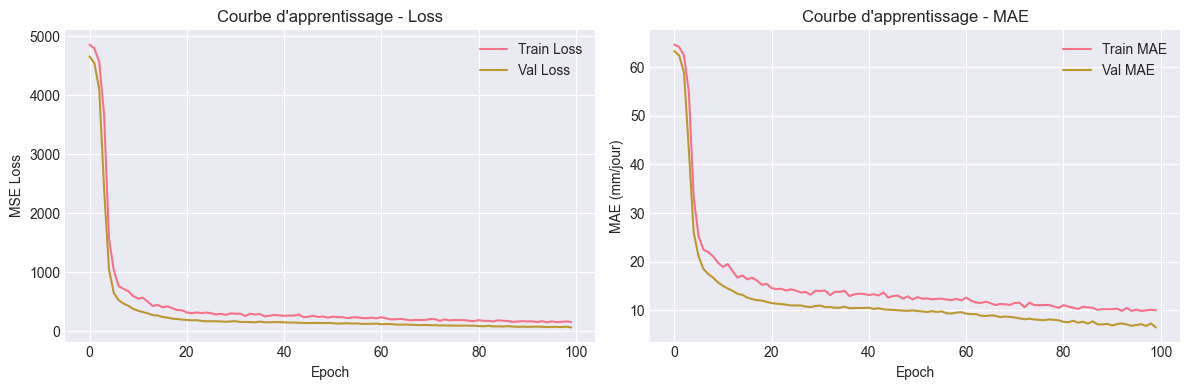

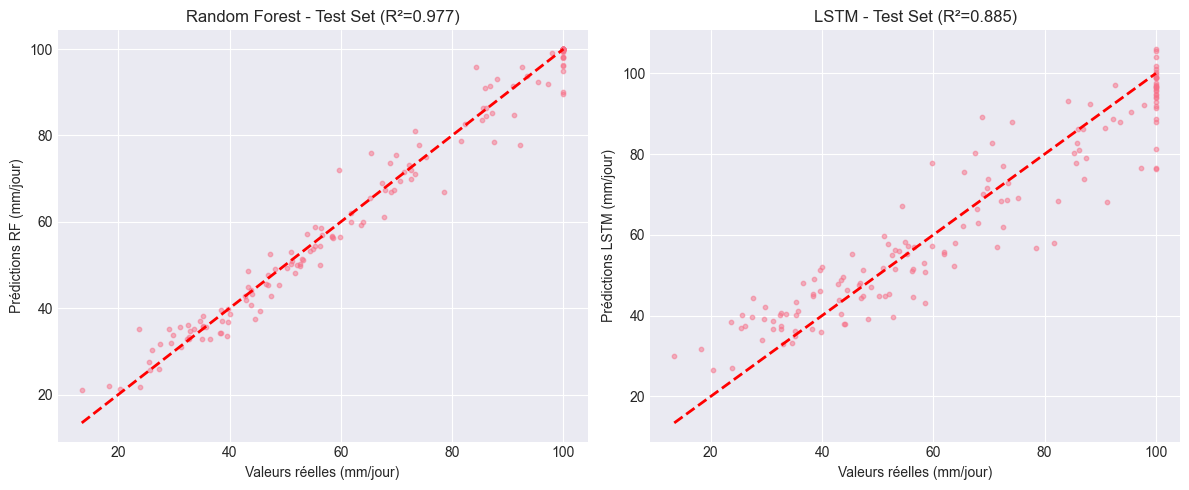

In [10]:
# ============================================================================
# 6. COMPARAISON DES MODÈLES
# ============================================================================

print("\n" + "="*60)
print("📊 COMPARAISON DES MODÈLES")
print("="*60)

comparison = pd.DataFrame({
    'Modèle': ['Random Forest', 'LSTM'],
    'MAE Test': [rf_test_metrics['mae'], lstm_test_metrics['mae']],
    'RMSE Test': [rf_test_metrics['rmse'], lstm_test_metrics['rmse']],
    'R² Test': [rf_test_metrics['r2'], lstm_test_metrics['r2']]
})

print(comparison.to_string(index=False))

# Visualisation de la courbe d'apprentissage LSTM
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Courbe d\'apprentissage - Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (mm/jour)')
plt.title('Courbe d\'apprentissage - MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/training_curves.png', dpi=150)
print(f"✓ Courbes sauvegardées: {MODEL_DIR}/training_curves.png")

# Prédictions vs Réalité
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs réelles (mm/jour)')
plt.ylabel('Prédictions RF (mm/jour)')
plt.title(f'Random Forest - Test Set (R²={rf_test_metrics["r2"]:.3f})')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred_lstm, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs réelles (mm/jour)')
plt.ylabel('Prédictions LSTM (mm/jour)')
plt.title(f'LSTM - Test Set (R²={lstm_test_metrics["r2"]:.3f})')
plt.grid(True)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/predictions_comparison.png', dpi=150)
print(f"✓ Comparaison sauvegardée: {MODEL_DIR}/predictions_comparison.png")


In [12]:
# ============================================================================
# 7. TEST RAPIDE DU MODÈLE
# ============================================================================

print("\n" + "="*60)
print("🧪 TEST RAPIDE DU MODÈLE")
print("="*60)

# Charger le modèle sauvegardé
#loaded_model = keras.models.load_model(f'{MODEL_DIR}/water_model.h5')
loaded_model = keras.models.load_model(f'{MODEL_DIR}/water_model.keras')
loaded_scaler = joblib.load(f'{MODEL_DIR}/water_scaler.pkl')

# Exemple de prédiction
sample = {
    'temperature_celsius': 28.5,
    'humidity_percent': 75.0,
    'rainfall_mm': 5.0,
    'evapotranspiration_mm': 4.5,
    'wind_speed_kmh': 12.0,
    'soil_moisture_percent': 65.0,
    'soil_type_encoded': 0,  # clay
    'growth_stage_encoded': 1,  # vegetative
    'irrigation_method_encoded': 1  # sri
}

sample_array = np.array([[sample[f] for f in ALL_FEATURES]])
sample_scaled = loaded_scaler.transform(sample_array)
sample_lstm = sample_scaled.reshape((1, 1, sample_scaled.shape[1]))

prediction = loaded_model.predict(sample_lstm)[0][0]

print(f"\n📊 Exemple de prédiction:")
print(f"   Température: {sample['temperature_celsius']}°C")
print(f"   Humidité: {sample['humidity_percent']}%")
print(f"   Pluie: {sample['rainfall_mm']} mm")
print(f"   → Besoin en eau prédit: {prediction:.2f} mm/jour")



🧪 TEST RAPIDE DU MODÈLE


C:\Users\PC\anaconda3\envs\tf310\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step

📊 Exemple de prédiction:
   Température: 28.5°C
   Humidité: 75.0%
   Pluie: 5.0 mm
   → Besoin en eau prédit: 46.58 mm/jour


In [13]:
# ============================================================================
# 8. RAPPORT FINAL
# ============================================================================

print("\n" + "="*60)
print("✅ ENTRAÎNEMENT TERMINÉ")
print("="*60)

report = f"""
RAPPORT D'ENTRAÎNEMENT - {datetime.now().strftime('%Y-%m-%d %H:%M')}

📊 DONNÉES:
   - Train: {len(train_df)} échantillons
   - Val:   {len(val_df)} échantillons
   - Test:  {len(test_df)} échantillons

🌲 RANDOM FOREST:
   - MAE Test:  {rf_test_metrics['mae']:.2f} mm/jour
   - RMSE Test: {rf_test_metrics['rmse']:.2f} mm/jour
   - R² Test:   {rf_test_metrics['r2']:.4f}

🧠 LSTM:
   - MAE Test:  {lstm_test_metrics['mae']:.2f} mm/jour
   - RMSE Test: {lstm_test_metrics['rmse']:.2f} mm/jour
   - R² Test:   {lstm_test_metrics['r2']:.4f}

🏆 MEILLEUR MODÈLE: {'LSTM' if lstm_test_metrics['mae'] < rf_test_metrics['mae'] else 'Random Forest'}

📁 FICHIERS GÉNÉRÉS:
   - {MODEL_DIR}/water_model.h5 (LSTM - À utiliser dans l'API)
   - {MODEL_DIR}/water_model_rf.pkl (Random Forest)
   - {MODEL_DIR}/water_scaler.pkl (Normalisation)
   - {MODEL_DIR}/eda_analysis.png
   - {MODEL_DIR}/training_curves.png
   - {MODEL_DIR}/predictions_comparison.png

✅ Le modèle est prêt à être utilisé dans l'API FastAPI !
"""

print(report)

# Sauvegarder le rapport
with open(f'{MODEL_DIR}/training_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print(f"\n📄 Rapport sauvegardé: {MODEL_DIR}/training_report.txt")
print("\n🎉 TOUT EST PRÊT ! Relance ton API pour utiliser le nouveau modèle.")


✅ ENTRAÎNEMENT TERMINÉ

RAPPORT D'ENTRAÎNEMENT - 2025-11-02 15:02

📊 DONNÉES:
   - Train: 700 échantillons
   - Val:   150 échantillons
   - Test:  150 échantillons

🌲 RANDOM FOREST:
   - MAE Test:  2.65 mm/jour
   - RMSE Test: 3.93 mm/jour
   - R² Test:   0.9771

🧠 LSTM:
   - MAE Test:  6.87 mm/jour
   - RMSE Test: 8.79 mm/jour
   - R² Test:   0.8852

🏆 MEILLEUR MODÈLE: Random Forest

📁 FICHIERS GÉNÉRÉS:
   - api/ml/water_model.h5 (LSTM - À utiliser dans l'API)
   - api/ml/water_model_rf.pkl (Random Forest)
   - api/ml/water_scaler.pkl (Normalisation)
   - api/ml/eda_analysis.png
   - api/ml/training_curves.png
   - api/ml/predictions_comparison.png

✅ Le modèle est prêt à être utilisé dans l'API FastAPI !


📄 Rapport sauvegardé: api/ml/training_report.txt

🎉 TOUT EST PRÊT ! Relance ton API pour utiliser le nouveau modèle.
